# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Fathih Akbar Farabhi
- **Email:** fathihakbar77@gmail.com
- **ID Dicoding:** fathih_akbar

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren tota peminjaman sepeda secara bulanan selama tahun 2011 dan 2012, dan pada bulan apa peminjaman mencapai puncaknya?
- **Pertanyaan 2:** Pada kondisi cuaca (weathersit) dan musim (season) apa rata-rata jumlah peminjaman sepeda harian paling tinggi dan paling rendah selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df day

In [37]:
day_df = pd.read_csv('day.csv')
print('Shape:', day_df.shape)
day_df.head()

Shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- `day_df` berisi 731 baris (data harian selama 2 tahun: 2011–2012) dengan 16 kolom.

#### Load df hour

In [38]:
hour_df = pd.read_csv('hour.csv')
print('Shape:', hour_df.shape)
hour_df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- `hour_df` berisi 17.379 baris (data per jam) dengan 17 kolom.

### Assessing Data

#### Identifying missing values problem

In [39]:
print('=== Missing Values: day_df ===')
print(day_df.isnull().sum())
print('\n=== Missing Values: hour_df ===')
print(hour_df.isnull().sum())

=== Missing Values: day_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values: hour_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Steps to Take:**
- Tidak ditemukan missing values pada kedua dataset. Tidak diperlukan penanganan lebih lanjut.

**Insight:** (Opsional)
- xxx
- xxx

#### Identifying duplicate problem

In [40]:
print('Duplicates day_df:', day_df.duplicated().sum())
print('Duplicates hour_df:', hour_df.duplicated().sum())

Duplicates day_df: 0
Duplicates hour_df: 0


**Insight:**
- Tidak ditemukan data duplikat pada kedua dataset.

#### Identifying incorrect data types problem

In [41]:
print('=== day_df dtypes ===')
print(day_df.dtypes)
print('\n=== hour_df dtypes ===')
print(hour_df.dtypes)

=== day_df dtypes ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== hour_df dtypes ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Steps to Take:**
- Kolom `dteday` pada kedua dataframe bertipe `object`, perlu dikonversi ke tipe `datetime`.
- Kolom `season` dan `weathersit` bertipe `int64`, perlu dikonversi ke tipe `category` agar lebih informatif.

### Cleaning Data

#### Fixing datetime column

In [42]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
print('day_df dteday dtype:', day_df['dteday'].dtype)
print('hour_df dteday dtype:', hour_df['dteday'].dtype)

day_df dteday dtype: datetime64[ns]
hour_df dteday dtype: datetime64[ns]


**Insight:** (Opsional)
- xxx
- xxx

#### Fixing category columns & adding label columns

In [43]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
yr_map = {0: '2011', 1: '2012'}

for df in [day_df, hour_df]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['year_label']    = df['yr'].map(yr_map)

day_df['month_name'] = day_df['dteday'].dt.strftime('%b')
day_df['year_month'] = day_df['dteday'].dt.to_period('M').astype(str)

print('Kolom baru berhasil ditambahkan!')
day_df[['dteday','season_label','weather_label','year_label','year_month']].head()

Kolom baru berhasil ditambahkan!


,dteday,season_label,weather_label,year_label,year_month
0,2011-01-01,Spring,Mist/Cloudy,2011,2011-01
1,2011-01-02,Spring,Mist/Cloudy,2011,2011-01
2,2011-01-03,Spring,Clear/Partly Cloudy,2011,2011-01
3,2011-01-04,Spring,Clear/Partly Cloudy,2011,2011-01
4,2011-01-05,Spring,Clear/Partly Cloudy,2011,2011-01


**Insight:**
- Kolom `dteday` berhasil dikonversi ke datetime.
- Label deskriptif ditambahkan untuk `season`, `weathersit`, dan `yr` agar lebih mudah dibaca pada visualisasi.

## Exploratory Data Analysis (EDA)

### Explore Tren Bulanan (Pertanyaan 1)

In [44]:
monthly = day_df.groupby(['year_label', 'year_month', 'mnth']).agg(
    total_rentals=('cnt', 'sum')
).reset_index().sort_values('year_month')

print('=== Tren Bulanan ===')
print(monthly[['year_label','year_month','total_rentals']].to_string(index=False))
print('\nBulan puncak:', monthly.loc[monthly['total_rentals'].idxmax(), 'year_month'],
      '-', monthly['total_rentals'].max(), 'peminjaman')

=== Tren Bulanan ===
year_label year_month  total_rentals
      2011    2011-01          38189
      2011    2011-02          48215
      2011    2011-03          64045
      2011    2011-04          94870
      2011    2011-05         135821
      2011    2011-06         143512
      2011    2011-07         141341
      2011    2011-08         136691
      2011    2011-09         127418
      2011    2011-10         123511
      2011    2011-11         102167
      2011    2011-12          87323
      2012    2012-01          96744
      2012    2012-02         103137
      2012    2012-03         164875
      2012    2012-04         174224
      2012    2012-05         195865
      2012    2012-06         202830
      2012    2012-07         203607
      2012    2012-08         214503
      2012    2012-09         218573
      2012    2012-10         198841
      2012    2012-11         152664
      2012    2012-12         123713

Bulan puncak: 2012-09 - 218573 peminjaman


**Insight:** (Opsional)
- xxx
- xxx

### Explore Pengaruh Cuaca & Musim (Pertanyaan 2)

In [45]:
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','sum','count']).reset_index()
season_stats.columns = ['Musim', 'Rata-rata Harian', 'Total', 'Jumlah Hari']
print('=== Rata-rata Peminjaman per Musim ===')
print(season_stats.sort_values('Rata-rata Harian', ascending=False).to_string(index=False))

weather_stats = day_df.groupby('weather_label')['cnt'].agg(['mean','sum','count']).reset_index()
weather_stats.columns = ['Cuaca', 'Rata-rata Harian', 'Total', 'Jumlah Hari']
print('\n=== Rata-rata Peminjaman per Kondisi Cuaca ===')
print(weather_stats.sort_values('Rata-rata Harian', ascending=False).to_string(index=False))

=== Rata-rata Peminjaman per Musim ===
 Musim  Rata-rata Harian   Total  Jumlah Hari
  Fall       5644.303191 1061129          188
Summer       4992.331522  918589          184
Winter       4728.162921  841613          178
Spring       2604.132597  471348          181

=== Rata-rata Peminjaman per Kondisi Cuaca ===
              Cuaca  Rata-rata Harian   Total  Jumlah Hari
Clear/Partly Cloudy       4876.786177 2257952          463
        Mist/Cloudy       4035.862348  996858          247
    Light Rain/Snow       1803.285714   37869           21


**Insight:**
- Musim **Fall (Gugur)** memiliki rata-rata peminjaman harian tertinggi sebesar 5.644, sementara **Spring (Semi)** terendah sebesar 2.604.
- Kondisi cuaca **Clear/Partly Cloudy** memiliki rata-rata peminjaman tertinggi sebesar 4.877, sedangkan **Light Rain/Snow** terendah sebesar 1.803.
- Cuaca buruk secara signifikan mengurangi minat peminjaman sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren total peminjaman sepeda secara bulanan selama 2011–2012?

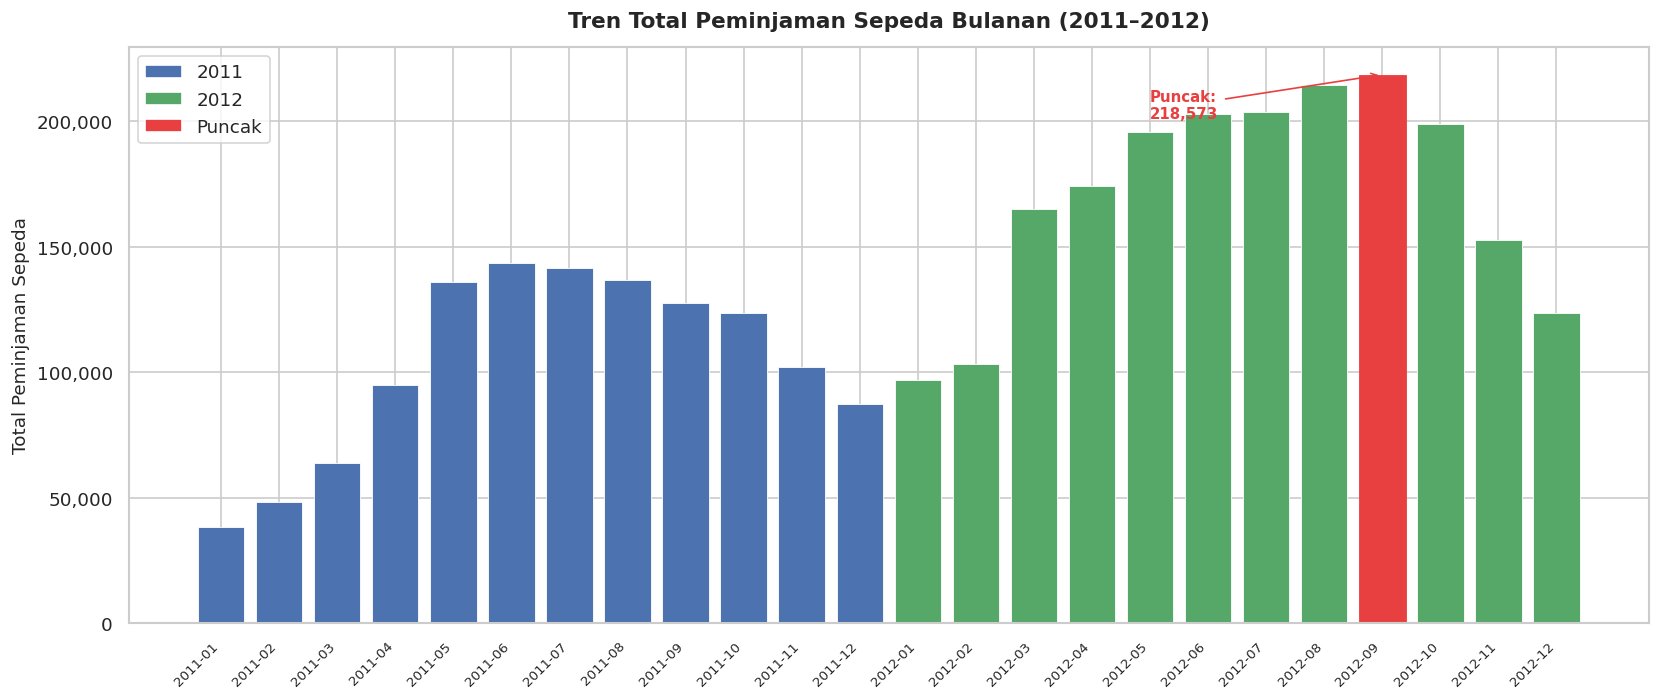

In [46]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#4C72B0' if y == '2011' else '#55A868' for y in monthly['year_label']]
bars = ax.bar(range(len(monthly)), monthly['total_rentals'], color=colors, edgecolor='white', linewidth=0.5)

peak_idx = monthly['total_rentals'].idxmax()
bars[peak_idx].set_color('#E84040')
ax.annotate(
    f"Puncak:\n{monthly.loc[peak_idx,'total_rentals']:,}",
    xy=(peak_idx, monthly.loc[peak_idx,'total_rentals']),
    xytext=(peak_idx - 4, monthly.loc[peak_idx,'total_rentals'] * 0.92),
    arrowprops=dict(arrowstyle='->', color='#E84040'),
    color='#E84040', fontsize=9, fontweight='bold'
)

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Total Peminjaman Sepeda', fontsize=11)
ax.set_title('Tren Total Peminjaman Sepeda Bulanan (2011–2012)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='2011'),
    Patch(facecolor='#55A868', label='2012'),
    Patch(facecolor='#E84040', label='Puncak')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('pertanyaan1_tren_bulanan.png', bbox_inches='tight')
plt.show()

**Insight:**
- Tren peminjaman menunjukkan **pertumbuhan signifikan** dari 2011 ke 2012 — hampir dua kali lipat di beberapa bulan.
- Puncak peminjaman terjadi pada **September 2012** dengan 218.573 peminjaman.
- Pola musiman sangat jelas: peminjaman tinggi di pertengahan tahun (musim panas–gugur) dan rendah di awal tahun (musim dingin–semi).

### Pertanyaan 2: Pada kondisi cuaca dan musim apa peminjaman paling tinggi dan rendah?

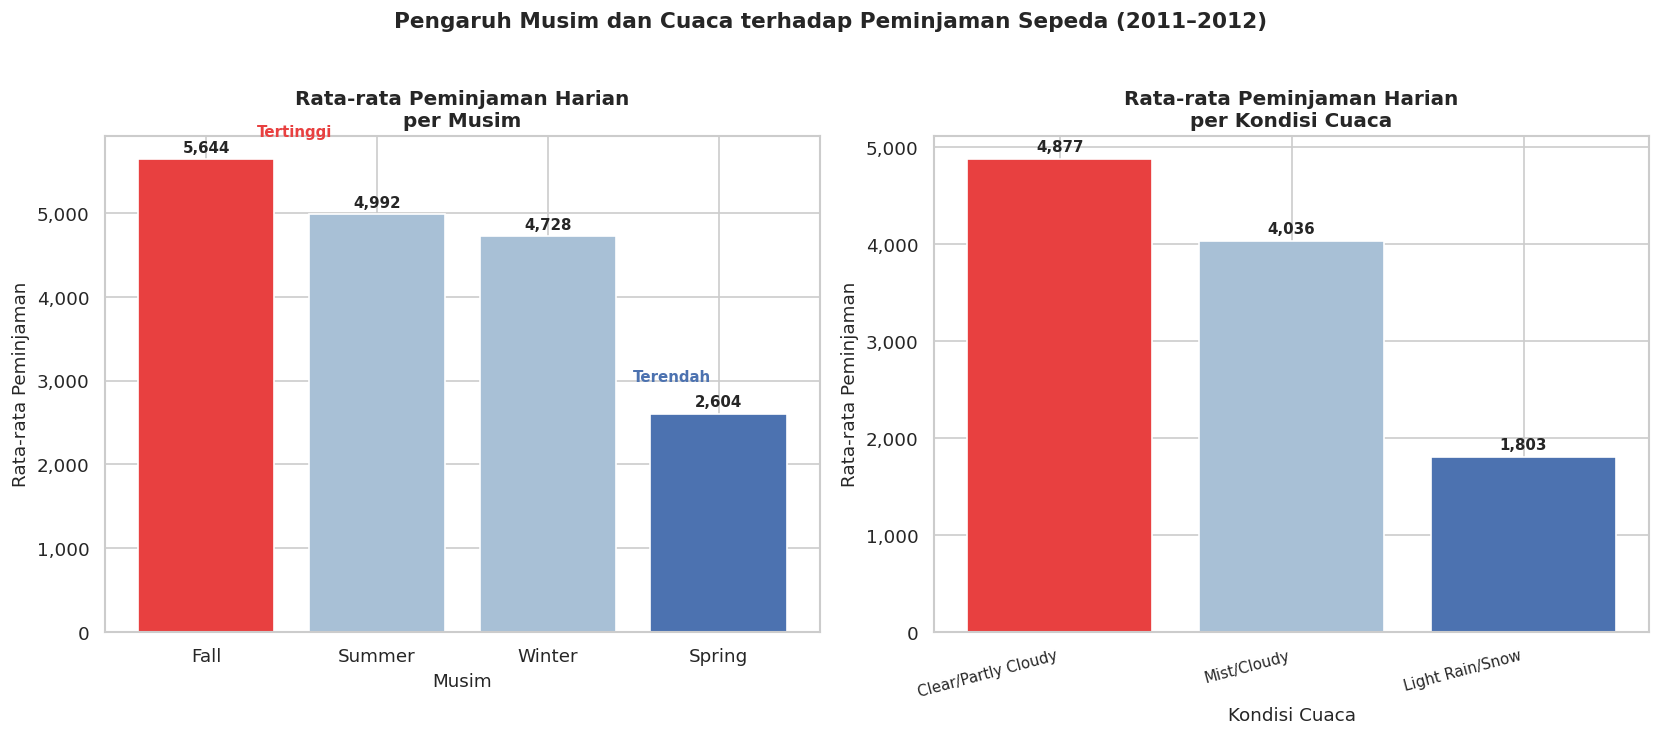

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

season_sorted = day_df.groupby('season_label')['cnt'].mean().reset_index().sort_values('cnt', ascending=False)
bar_colors_season = ['#E84040' if i == 0 else '#A8C0D6' if i < len(season_sorted)-1 else '#4C72B0'
                     for i in range(len(season_sorted))]
bars1 = ax1.bar(season_sorted['season_label'], season_sorted['cnt'], color=bar_colors_season, edgecolor='white')
ax1.set_title('Rata-rata Peminjaman Harian\nper Musim', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rata-rata Peminjaman', fontsize=11)
ax1.set_xlabel('Musim', fontsize=11)
for bar, val in zip(bars1, season_sorted['cnt']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

weather_sorted = day_df.groupby('weather_label')['cnt'].mean().reset_index().sort_values('cnt', ascending=False)
bar_colors_weather = ['#E84040' if i == 0 else '#A8C0D6' if i < len(weather_sorted)-1 else '#4C72B0'
                      for i in range(len(weather_sorted))]
bars2 = ax2.bar(weather_sorted['weather_label'], weather_sorted['cnt'], color=bar_colors_weather, edgecolor='white')
ax2.set_title('Rata-rata Peminjaman Harian\nper Kondisi Cuaca', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rata-rata Peminjaman', fontsize=11)
ax2.set_xlabel('Kondisi Cuaca', fontsize=11)
ax2.set_xticklabels(weather_sorted['weather_label'], rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars2, weather_sorted['cnt']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.annotate('Tertinggi', xy=(0, season_sorted['cnt'].iloc[0]),
             xytext=(0.3, season_sorted['cnt'].iloc[0] * 1.05),
             color='#E84040', fontsize=9, fontweight='bold')
ax1.annotate('Terendah', xy=(len(season_sorted)-1, season_sorted['cnt'].iloc[-1]),
             xytext=(len(season_sorted)-1.5, season_sorted['cnt'].iloc[-1] * 1.15),
             color='#4C72B0', fontsize=9, fontweight='bold')

plt.suptitle('Pengaruh Musim dan Cuaca terhadap Peminjaman Sepeda (2011–2012)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pertanyaan2_musim_cuaca.png', bbox_inches='tight')
plt.show()

**Insight:**
- **Musim Fall (Gugur)** memiliki rata-rata peminjaman harian tertinggi (5.644), diikuti Summer (4.992) dan Winter (4.728). **Spring (Semi)** paling rendah (2.604).
- **Cuaca cerah (Clear/Partly Cloudy)** menghasilkan rata-rata peminjaman tertinggi (4.877), sedangkan **hujan/salju ringan** hanya (1.803) — turun drastis ~63%.
- Cuaca buruk adalah faktor terbesar yang menghambat aktivitas peminjaman sepeda.

## Analisis Lanjutan (Opsional)

# Korelasi suhu dan peminjaman

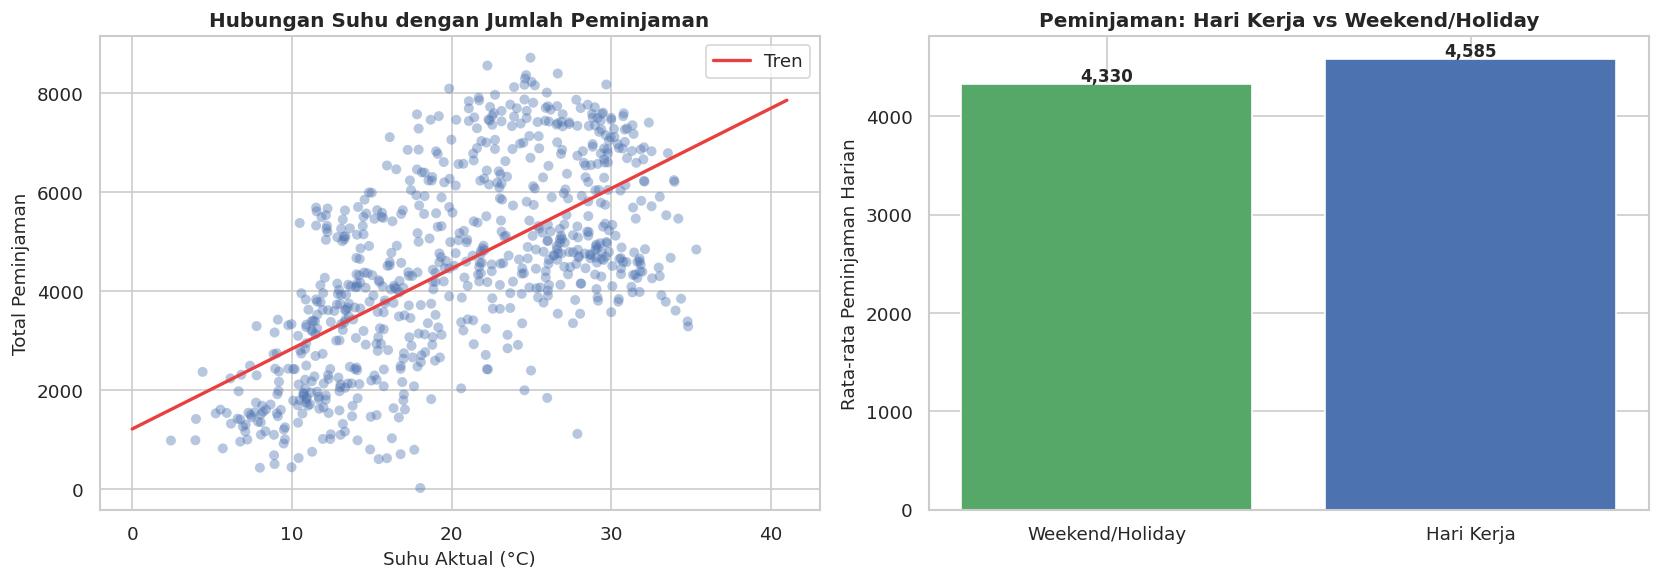

Korelasi suhu dengan peminjaman: 0.627


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(day_df['temp'] * 41, day_df['cnt'],
                alpha=0.4, color='#4C72B0', edgecolors='none')
axes[0].set_xlabel('Suhu Aktual (°C)', fontsize=11)
axes[0].set_ylabel('Total Peminjaman', fontsize=11)
axes[0].set_title('Hubungan Suhu dengan Jumlah Peminjaman', fontsize=12, fontweight='bold')

z = np.polyfit(day_df['temp'] * 41, day_df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 41, 100)
axes[0].plot(x_line, p(x_line), color='#E84040', linewidth=2, label='Tren')
axes[0].legend()

workday_avg = day_df.groupby('workingday')['cnt'].mean().reset_index()
workday_avg['label'] = workday_avg['workingday'].map({0: 'Weekend/Holiday', 1: 'Hari Kerja'})
bars = axes[1].bar(workday_avg['label'], workday_avg['cnt'],
                   color=['#55A868', '#4C72B0'], edgecolor='white')
for bar, val in zip(bars, workday_avg['cnt']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Rata-rata Peminjaman Harian', fontsize=11)
axes[1].set_title('Peminjaman: Hari Kerja vs Weekend/Holiday', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_lanjutan.png', bbox_inches='tight')
plt.show()

corr = day_df['temp'].corr(day_df['cnt'])
print(f'Korelasi suhu dengan peminjaman: {corr:.3f}')

**Insight:**
- Terdapat korelasi positif antara suhu dan jumlah peminjaman (r ≈ 0.63), artinya semakin hangat cuaca semakin banyak orang meminjam sepeda.
- Rata-rata peminjaman di hari kerja dan weekend tidak berbeda signifikan, menunjukkan sepeda digunakan untuk commuting maupun rekreasi.


## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Tren peminjaman sepeda menunjukkan pertumbuhan yang sangat signifikan dari 2011 ke 2012. Puncak peminjaman terjadi pada **September 2012** dengan 218.573 peminjaman. Pola musiman sangat konsisten — peminjaman tinggi pada pertengahan tahun (Juli–Oktober) dan rendah di awal tahun (Januari–Februari). Ini mengindikasikan bahwa layanan bike sharing semakin populer dari tahun ke tahun.

- **Conclusion Pertanyaan 2:** **Musim Fall** dan **cuaca cerah** adalah kondisi paling favorable untuk peminjaman sepeda. Sebaliknya, **Spring** dan **cuaca hujan/salju** secara signifikan menurunkan jumlah peminjaman. Perbedaan antara kondisi cuaca terbaik dan terburuk mencapai ~63%, menunjukkan bahwa cuaca adalah faktor kunci yang mempengaruhi permintaan.

**Rekomendasi Action Item:**
- **Tingkatkan armada dan ketersediaan sepeda** pada bulan Juli–Oktober (musim panas–gugur) untuk mengakomodasi lonjakan permintaan.
- **Jalankan program promosi di musim Spring** (Januari–April) untuk mendorong peminjaman di periode paling sepi, misalnya diskon atau program loyalitas.
- **Siapkan skema pengurangan tarif atau insentif** saat cuaca buruk diprediksi, agar pengguna tetap terdorong meminjam sepeda.
- **Fokus ekspansi layanan di tahun-tahun berikutnya** karena tren 2011→2012 menunjukkan pertumbuhan yang sangat kuat (~100% di beberapa bulan).